In [ ]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [ ]:
X = housing['data']
y = housing['target']

from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

In [ ]:
# !pip install torchmetrics

In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

Epoch: 1/20, loss: 1.0714728040800279, train_metric: 0.728, valid_metric: 0.53, 
Epoch: 2/20, loss: 0.5329146932800283, train_metric: 0.536, valid_metric: 0.571, 
Epoch: 3/20, loss: 0.4762775705660342, train_metric: 0.502, valid_metric: 0.483, 
Epoch: 4/20, loss: 0.44502814360393966, train_metric: 0.482, valid_metric: 0.457, 
Epoch: 5/20, loss: 0.4313284534314447, train_metric: 0.473, valid_metric: 0.454, 
Epoch: 6/20, loss: 0.4237095182838519, train_metric: 0.469, valid_metric: 0.456, 
Epoch: 7/20, loss: 0.41679922050024193, train_metric: 0.464, valid_metric: 0.452, 
Epoch: 8/20, loss: 0.4110565276677943, train_metric: 0.461, valid_metric: 0.453, 
Epoch: 9/20, loss: 0.4077061045678851, train_metric: 0.457, valid_metric: 0.466, 
Epoch: 10/20, loss: 0.40355990026607985, train_metric: 0.456, valid_metric: 0.447, 
Epoch: 11/20, loss: 0.40138071871903974, train_metric: 0.453, valid_metric: 0.451, 
Epoch: 12/20, loss: 0.3977144289936244, train_metric: 0.452, valid_metric: 0.434, 
Epoch: 13/

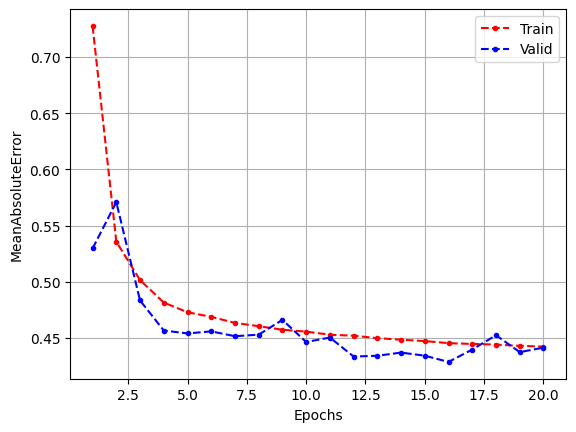

In [73]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

learning_rate = 0.1
n_epochs=20
device = 'cpu' # 'cuda'

# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=50, out_features=1)
# ).to(device)
class Model1(nn.Module):
	def __init__(self, n_features=8):
		super().__init__()
		self.stack = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.Sigmoid(),
			nn.Linear(in_features=30, out_features=50), 
			nn.Sigmoid(),
			nn.Linear(in_features=50, out_features=1)
		)
        
	def forward(self, X):
		y = self.stack(X)
		return y
model = Model1().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = {
	'loss' : [],
	'train_metric' : [],
	'valid_metric' : [],
}
for epoch in range(n_epochs):
	# Training 
	total_loss = 0
	metric.reset()
	for X_batch, y_batch in train_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		model.train()
		y_pred = model(X_batch)
		loss = criterion(y_pred, y_batch)
		total_loss += loss.item()
		loss.backward()
		optimizer.step()
		optimizer.zero_grad()
		metric.update(y_pred, y_batch)
	
	avg_loss = total_loss / len(train_loader)
	history['loss'].append(avg_loss)

	avg_metric_train = metric.compute().item()
	history['train_metric'].append(avg_metric_train)

	# Evaluation 
	model.eval()
	metric.reset()
	for X_batch, y_batch in valid_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		with torch.no_grad():
			y_pred = model(X_batch)
			metric.update(y_pred, y_batch)

	avg_metric_valid = metric.compute().item()
	history['valid_metric'].append(avg_metric_valid)

	print(f'Epoch: {epoch+1}/{n_epochs}, loss: {avg_loss}, train_metric: {round(avg_metric_train,3)}, valid_metric: {round(avg_metric_valid,3)}, ')

	# if epoch>=2:
	# 	break

plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
plt.legend()
plt.grid()
plt.xlabel('Epochs')
plt.ylabel(f'{metric.__class__.__name__}')
plt.show()

In [71]:
# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=50, out_features=1)
# ).to(device)

class Model1(nn.Module):
	def __init__(self, n_features=8):
		super().__init__()
		self.stack = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.Sigmoid(),
			nn.Linear(in_features=30, out_features=50), 
			nn.Sigmoid(),
			nn.Linear(in_features=50, out_features=1)
		)
        
	def forward(self, X):
		y = self.stack(X)
		return y
    
model = Model1()
model(X_batch)

tensor([[-0.0849],
        [-0.0849],
        [-0.0654],
        [-0.0496],
        [-0.0851],
        [-0.0902],
        [-0.0646],
        [-0.0639],
        [-0.0665],
        [-0.0779],
        [-0.0497],
        [-0.0804],
        [-0.0790],
        [-0.0520],
        [-0.0721],
        [-0.0512],
        [-0.0760],
        [-0.0816],
        [-0.0719],
        [-0.0783],
        [-0.0705],
        [-0.0720],
        [-0.0724],
        [-0.0737],
        [-0.0717],
        [-0.0476],
        [-0.0548],
        [-0.0714],
        [-0.0846],
        [-0.0785]], grad_fn=<AddmmBackward0>)

In [67]:
class Adam:
    def __init__(self, ad, soyad=None):
        self.ad = ad
        self.soyad = soyad

class Talaba(Adam):
	def __init__(self, ad, soyad=None, ish=False):
		super().__init__(ad, soyad)
		self.ish = ish

	def oxu(self, neyi='kitabi'):
		return f'oxuyuram {neyi}'

t1 = Talaba(ad='Hesen')
t1.oxu()

'oxuyuram kitabi'